In [1]:
import numpy as np
import dolfinx
from mpi4py import MPI
from petsc4py import PETSc
import ufl
from dolfinx.mesh import create_interval
from dolfinx.fem import Function, functionspace, dirichletbc, locate_dofs_geometrical
from dolfinx.fem.petsc import LinearProblem

In [2]:
# Mesh
mesh = create_interval(MPI.COMM_WORLD, 50, [0,1])
V = functionspace(mesh, ("CG", 1))

In [3]:
# Boundary conditions
def left(x):
    return np.isclose(x[0], 0)

def right(x):
    return np.isclose(x[0], 1)

uL = Function(V)
uL.x.array[:] = 0

uR = Function(V)

In [4]:
# Time dependent BC
t = 0
def update_bc():
    uR.x.array[:] = np.sin(2*np.pi*t)

bcL = dirichletbc(uL, locate_dofs_geometrical(V, left))
bcR = dirichletbc(uR, locate_dofs_geometrical(V, right))

In [5]:
# Initial condition and Variational Form
u_n = Function(V)
u_n.interpolate(lambda x: np.sin(np.pi*x[0]) + 0.5*np.sin(3*np.pi*x[0]))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

dt = 0.01
alpha = 1.0

a = u*v*ufl.dx + dt*alpha*ufl.dot(ufl.grad(u), ufl.grad(v))*ufl.dx
L = (u_n*v)*ufl.dx

problem = LinearProblem(a, L, bcs=[bcL, bcR], petsc_options_prefix="linear_solver")

In [6]:
# Time loop
for step in range(50):
    t += dt
    update_bc()
    
    uh = problem.solve()
    u_n.x.array[:] = uh.x.array

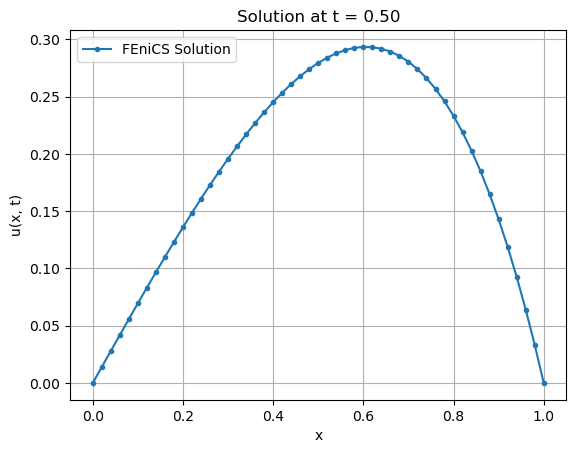

In [7]:
import matplotlib.pyplot as plt

x = V.tabulate_dof_coordinates()[:, 0]
y = u_n.x.array

# Sort for plotting
sort_idx = np.argsort(x)
plt.plot(x[sort_idx], y[sort_idx], marker=".", linestyle="-", label="FEniCS Solution")
plt.title(f"Solution at t = {t:.2f}")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.grid(True)
plt.show()
